### Flux VAE test

1) loads pretrained flux.2 VAE
2) tests it on some image (encode + decode)
3) shows some intermediate steps

In [ ]:
from diffusers.models import AutoencoderKLFlux2
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
import time

device = "cuda"

In [3]:
vae = AutoencoderKLFlux2.from_pretrained("../FLUX.2-klein-4B/vae", device=device).to(device)

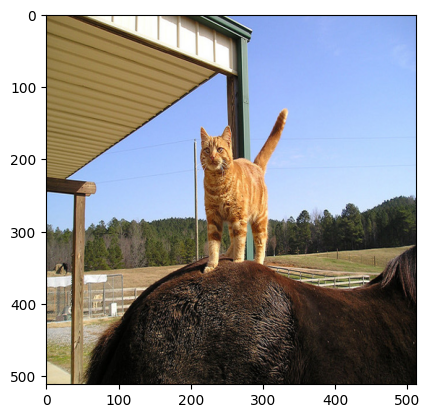

torch.Size([1, 3, 512, 512])
tensor(0., device='cuda:0') tensor(1., device='cuda:0')


In [42]:
transform = transforms.Compose([transforms.ToTensor()])
img = Image.open("../coco2017/train2017/000000001323.jpg").convert("RGB")
img = img.resize((512, 512))
plt.imshow(img)
plt.show()

img_tensor = transform(img)
img_tensor = img_tensor.unsqueeze(0).cuda()
print(img_tensor.shape)
print(img_tensor.min(), img_tensor.max())

torch.Size([1, 32, 64, 64])
tensor(-12.4927, device='cuda:0') tensor(8.8513, device='cuda:0')


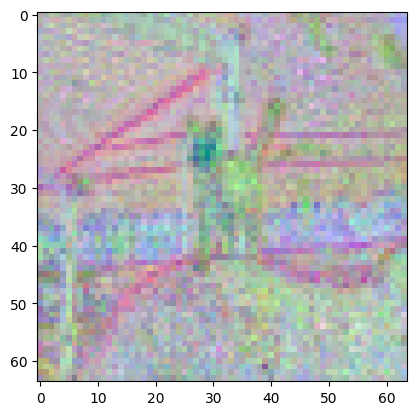

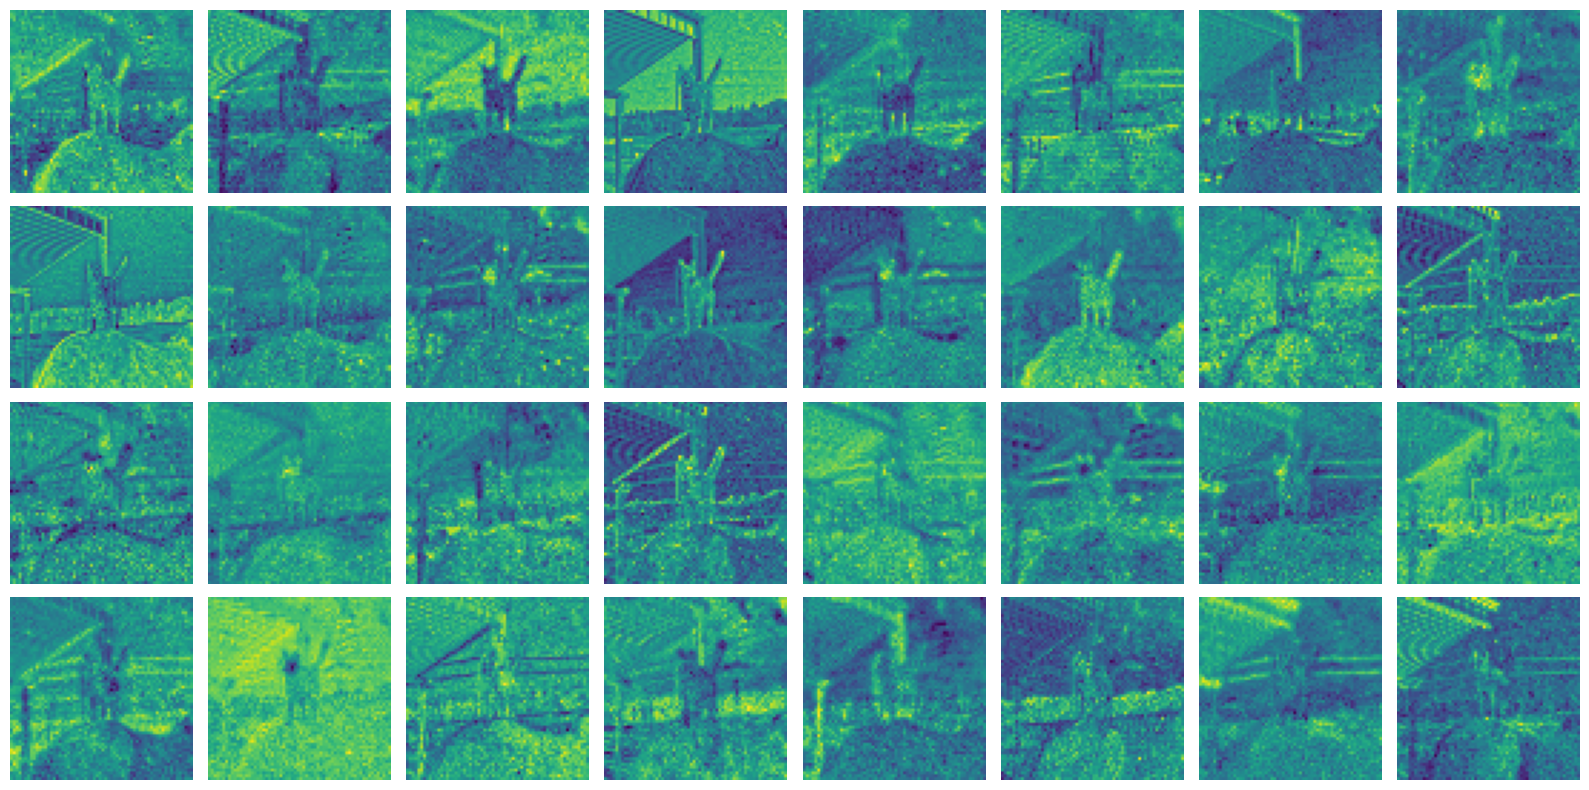

In [54]:
with torch.no_grad():
    image_norm = (img_tensor - 0.5) * 2
    latent = vae.encode(image_norm).latent_dist.mode()

print(latent.shape)
print(latent.min(), latent.max())

latents_np = latent.squeeze(0).permute((1, 2, 0)).cpu().numpy()[:,:,25:28] # some random 3 channels
latents_np = latents_np - latents_np.min()
latents_np = latents_np / latents_np.max()
plt.imshow(latents_np)
plt.show()

n = 32
rows = 4
cols = n // rows

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

a = 0
for i in range(0, n):
    latents_np = latent.squeeze(0).permute((1, 2, 0)).cpu().numpy()[:,:,i]
    latents_np = latents_np - latents_np.min()
    latents_np = latents_np / latents_np.max()
    axes[a // cols][a % cols].imshow(latents_np)
    axes[a // cols][a % cols].axis("off")
    a += 1

plt.tight_layout()
plt.show()


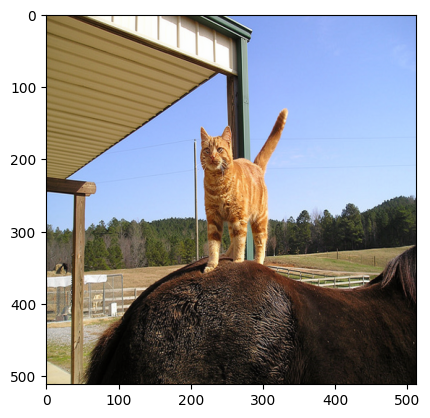

In [49]:
with torch.no_grad():
    reconstructed = (vae.decode(latent).sample + 1.0 ) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

In [58]:
for _ in range(10):
    t = time.time()
    with torch.no_grad():
        image_norm = (img_tensor - 0.5) * 2
        latent = vae.encode(image_norm).latent_dist.mode()
        
    torch.cuda.synchronize()
    print("encode time", time.time() - t)

encode time 0.025203943252563477
encode time 0.024488449096679688
encode time 0.023867130279541016
encode time 0.02384805679321289
encode time 0.02353358268737793
encode time 0.02344655990600586
encode time 0.022910356521606445
encode time 0.023478031158447266
encode time 0.023151397705078125
encode time 0.02432847023010254


In [62]:
118287 * 64 * 64 * 32 * 2 // 1024 // 1024 // 1024

28